In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from typing import Tuple

In [3]:
R = 1 # radius of lens, m (arbitrary value)

image = Image.open("fermat.png").convert("RGBA")
image_array = np.array(image)

obj_width = 0.4  # m
obj_height = 0.4  # m

# Pixel dimensions
h, w = image_array.shape[:2]

# starting pos
step = 0.1  # m
x_obj = 0.5
y_obj = 0.5

In [4]:
def map_real_image_in_concave_spherical_mirror(
    xy: Tuple[np.ndarray, np.ndarray],
) -> Tuple[np.ndarray, np.ndarray]:
    """Returns an array of coordinates for a real image of an object in a concave spherical mirror.

    Args:
        xy (Tuple[np.ndarray, np.ndarray]): The array of points of the original object.

    Returns:
        Tuple[np.ndarray, np.ndarray]: The array of points of the real image (X, Y).
    """
    x, y = xy
    theta = np.arctan(y / np.sqrt(R**2 - x**2))
    m = np.tan(2 * theta)

    # X, Y = image coords
    X = -(m * np.sqrt(R**2 - y**2) - y) / (y / x + m)
    Y = -(y * (m * np.sqrt(R**2 - y**2) - y**2)) / (x * (y / x + m))
    return (X, Y)


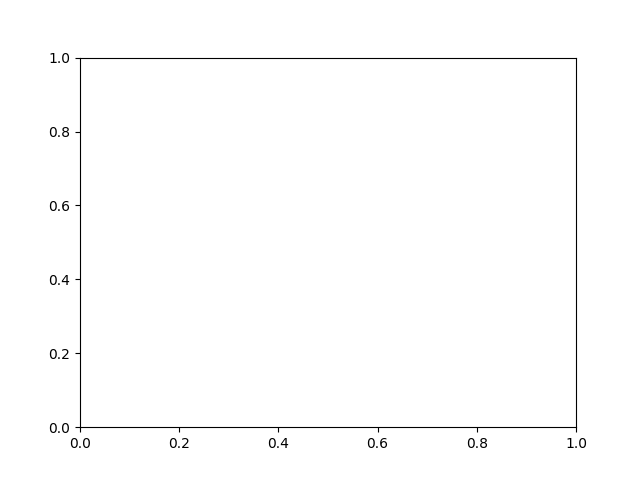

In [5]:
fig, ax = plt.subplots()

def plot_scene():
    ax.clear()

    # Plot the original object image (as if projected onto the scene)
    ax.imshow(
        image_array,
        extent=(
            x_obj - obj_width / 2,
            x_obj + obj_width / 2,
            y_obj - obj_height / 2,
            y_obj + obj_height / 2,
        ),
    )

    # Distorted image plotting
    x_lin = np.linspace(x_obj - obj_width / 2, x_obj + obj_width / 2, w)
    y_lin = np.linspace(y_obj - obj_height / 2, y_obj + obj_height / 2, h)
    xx, yy = np.meshgrid(x_lin, y_lin)

    # Mask to avoid division by zero or undefined lens mapping
    # Ensure mask is applied to xx, yy, and image_array consistently
    mask = (xx != 0) & (np.abs(yy) < R) & (yy.shape == image_array.shape[:2])

    # Apply the mirror transformation to the masked coordinates
    X, Y = map_real_image_in_concave_spherical_mirror((xx[mask], yy[mask]))

    if X.size == 0 or Y.size == 0:
        print("Warning: X or Y are empty after mapping, nothing to scatter.")

    pixels = np.flipud(image_array)[mask] / 255.0  # Normalize pixel values for scatter color
    ax.scatter(X, Y, c=pixels, s=1)  # Plot the distorted image as individual pixels

    # Plotting the semi-circle at (0,0) with radius R, only the left half
    # Angles from pi/2 (90 degrees) to 3*pi/2 (270 degrees) to get the left half
    theta_semi = np.linspace(np.pi / 2, 3 * np.pi / 2, 100)
    x_semi = R * np.cos(theta_semi)
    y_semi = R * np.sin(theta_semi)
    ax.plot(
        x_semi,
        y_semi,
        color="green",
        linestyle="-",
        linewidth=2,
        label=f"Mirror (Radius R={R})",
    )

    ax.axvline(0, color="blue", linestyle="--", linewidth=1)

    ax.set_title(
        f"Object at ({x_obj:.2f}, {y_obj:.2f}) and Real Distorted Image with Concave Spherical Mirror"
    )
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_xlabel("X / m")
    ax.set_ylabel("Y / m")
    ax.set_aspect("equal")
    ax.grid(True)
    ax.legend()

    fig.canvas.draw()


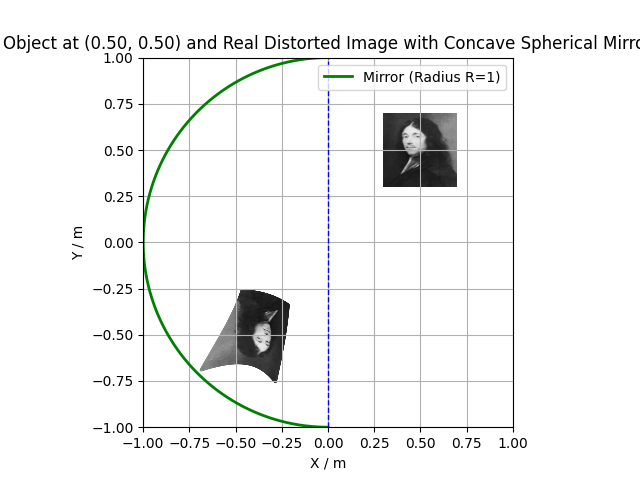

In [6]:
def on_key(event):
    global x_obj, y_obj
    if event.key == 'up':
        y_obj += step
    elif event.key == 'down':
        y_obj -= step
    elif event.key == 'left' and x_obj - step > 0.01:
        x_obj -= step
    elif event.key == 'right' and x_obj + step < 2 * R:
        x_obj += step
    plot_scene()

fig.canvas.mpl_connect('key_press_event', on_key)
plot_scene()
plt.show()